# PINN: Liniowa Sprężystość 2D (Model Bazowy - Baseline) — wersja poprawiona

**Założenia fizyczne (Doświadczenie):**
Symulujemy kwadratową blachę 2D o wymiarach 1×1 w Płaskim Stanie Naprężenia.

1. **Utwierdzenie D1 (Dirichlet BC):** Blacha jest przytrzymywana w jej środku (punkt `x=0.5, y=0.5`): przemieszczenia $u=0, v=0$
2. **Utwierdzenie D2 (Dirichlet BC):** Aby zapobiec obrotowi, narzucamy dodatkowo $v=0$ w rogu `(1.0, 0.0)`.
3. **Obciążenie (Neumann BC):** Działamy poziomą siłą normalną na małym fragmencie prawej krawędzi (dla $y \ge 0.9$): $T_x = \sigma_{xx} = 1{,}0$. Krawędź prawa ma normalną $\mathbf{n}=(1,0)$, więc składowa styczna $T_y = \sigma_{xy} = 0$ (brak naprężenia ścinającego na tej krawędzi).
4. **Swobodne brzegi (Traction-free):** Lewa, dolna i górna krawędź są swobodne ($\boldsymbol{\sigma}\cdot\mathbf{n} = 0$).

**Changelog vs. poprzednia wersja:**
- **Brak D2 BC**: dodano $v=0$ w `(1.0, 0.0)` — bez tego obrót był nieograniczony.
- **Błędne `loss_right`**: stary kod narzucał $\sigma_{xy} = 1\cdot\text{mask}$ (siła pionowa), co jest fizycznie niepoprawne dla prawej krawędzi. Poprawka: $\sigma_{xy} = 0$.
- **EPOCHS=15000 → 30000**: dłuższy horyzont trenowania.
- **Brak seedu inicjalizacji**: dodano `PINN_INIT_SEED=42` + `cudnn.deterministic=True` dla reprodukowalności.
- **LOG_INTERVAL=1000 → 500**: gęstszy zapis historii PDE/BC.


In [1]:
!pip install -q torch numpy matplotlib scipy

In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from typing import Callable, Tuple

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Używane urządzenie obliczeniowe: {device}")

Używane urządzenie obliczeniowe: cuda


## 1. Parametry Modelu

**Co realizuje ta komórka:**
Definiujemy tutaj wszystkie hiperparametry naszego modelu fizycznego oraz sieci neuronowej.

**Założenia:**
- `LENGTH`, `E`, `NU`: Parametry materiałowe i geometryczne blachy.
- `N_POINTS`: Liczba punktów na jednej osi dla siatki równomiernej (łącznie `N_POINTS * N_POINTS` punktów wewnątrz dziedziny).
- `WEIGHT_RESIDUAL`, `WEIGHT_BOUNDARY`: Wagi w funkcji straty, pozwalające balansować wpływ równań fizyki (PDE) i warunków brzegowych (BC).
- Parametry sieci: 4 warstwy ukryte po 80 neuronów, 3000 epok uczenia, optymalizator Adam z LR=0.002.

In [3]:
LENGTH = 1.0                 # Rozmiar dziedziny (kwadratowa blacha x, y)
E = 1.0                      # Moduł Younga (sztywność materiału)
NU = 0.3                     # Współczynnik Poissona (odkształcenie poprzeczne)

N_POINTS = 30                # Liczba punktów na siatce w jednej osi (30x30 = 900 punktów w dziedzinie)
N_BND_POINTS = 30            # Liczba punktów na każdej z krawędzi do warunków Neumanna

WEIGHT_RESIDUAL = 1.0        # Waga dla części residualnej (PDE Loss)
WEIGHT_BOUNDARY = 10.0       # Waga dla funkcji straty warunków brzegowych BC

LAYERS = 4                   # Liczba ukrytych warstw sieci PINN
NEURONS_PER_LAYER = 80       # Liczba neuronów na każdą warstwę ukrytą
EPOCHS = 30000               # Liczba epok trenowania (rozszerzona do 30k)
LEARNING_RATE = 0.002        # Szybkość uczenia optymalizatora Adam
LOG_INTERVAL = 500           # Co ile epok zapisujemy historię PDE/BC i wypisujemy stan

PINN_INIT_SEED = 42          # Seed inicjalizacji wag sieci (reprodukowalność)


## 2. Architektura Sieci PINN i Różniczkowanie Automatyczne

**Co realizuje ta komórka:**
Tworzymy klasę `PINN` dziedziczącą po `nn.Module`, która aproksymuje funkcję przemieszczeń $(u, v)$ na podstawie współrzędnych $(x, y)$. Definiujemy również funkcję `df` do obliczania pochodnych cząstkowych.

**Krok po kroku:**
1. **Klasa PINN:** Sieć przyjmuje 2 wejścia $(x, y)$ i zwraca 2 wyjścia $(u, v)$. Używamy aktywacji `Tanh`, ponieważ jest ona gładka i pozwala na obliczanie drugich pochodnych (niezbędnych w równaniach Naviera-Cauchy'ego)
2. **Funkcja `df`:** Wykorzystuje silnik `torch.autograd.grad` do obliczania dokładnych pochodnych analitycznych wyjścia względem wejścia.

In [4]:
class PINN(nn.Module):
    def __init__(self, num_hidden: int, dim_hidden: int, act=nn.Tanh()):
        super().__init__()
        
        self.layer_in = nn.Linear(2, dim_hidden)
        self.layer_out = nn.Linear(dim_hidden, 2)  # Zwracamy dwie cechy: [u, v]
        
        num_middle = num_hidden - 1
        self.middle_layers = nn.ModuleList(
            [nn.Linear(dim_hidden, dim_hidden) for _ in range(num_middle)]
        )
        self.act = act

    def forward(self, x, y):
        x_stack = torch.cat([x, y], dim=1)
        out = self.act(self.layer_in(x_stack))
        for layer in self.middle_layers:
            out = self.act(layer(out))
            
        logits = self.layer_out(out)
        
        # Wypuszczamy dwa osobne tensory: przemieszczenia U oraz V
        return logits[:, 0:1], logits[:, 1:2]

    def device(self):
        return next(self.parameters()).device

def f_eval(pinn: PINN, x: torch.Tensor, y: torch.Tensor):
    """Funkcja wejściowa - obliczająca przybliżenie przemieszczenia"""
    return pinn(x, y)

def df(output: torch.Tensor, input: torch.Tensor, order: int = 1) -> torch.Tensor:
    """Generuje w grafie PyTorcha kolejne rzędy pochodnych"""
    df_value = output
    for _ in range(order):
        df_value = torch.autograd.grad(
            df_value,
            input,
            grad_outputs=torch.ones_like(df_value), # POPRAWKA: grad_outputs musi pasować do df_value
            create_graph=True,
            retain_graph=True,
        )[0]
    return df_value

## 3. Generatory Punktów (Uniform Sampling)

**Co realizuje ta komórka:**
Funkcje odpowiedzialne za generowanie punktów kolokacji, w których sieć będzie "odpytywana" z praw fizyki.

**Krok po kroku:**
1. `get_interior_points`: Tworzy równomierną siatkę 30×30 = 900 punktów wewnątrz blachy.
2. `get_boundary_points`: Generuje punkty na czterech krawędziach blachy dla warunków Neumanna. Wymagają gradientu, ponieważ obliczamy na nich naprężenia.
3. `get_specific_point`: Zwraca konkretny punkt do nałożenia warunku Dirichleta.
   - **D1**: `(0.5, 0.5)` — środek blachy, $u=0, v=0$ (eliminacja translacji).
   - **D2**: `(1.0, 0.0)` — prawy dolny róg, $v=0$ (eliminacja obrotu).


In [5]:
def get_interior_points(x_domain: Tuple[float,float], y_domain: Tuple[float,float], n_points: int, device=torch.device("cpu"), requires_grad=True):
    """Zwykła równomierna siatka na blachach (zoptymalizowana pod PyTorch)"""
    x_lin = torch.linspace(x_domain[0], x_domain[1], steps=n_points, device=device)
    y_lin = torch.linspace(y_domain[0], y_domain[1], steps=n_points, device=device)
    grids = torch.meshgrid(x_lin, y_lin, indexing="ij")
    
    x = grids[0].reshape(-1, 1).requires_grad_(requires_grad)
    y = grids[1].reshape(-1, 1).requires_grad_(requires_grad)
    return x, y

def get_boundary_points(x_domain: Tuple[float,float], y_domain: Tuple[float,float], n_points: int, device=torch.device("cpu")):
    """Generuje punkty na 4 krawędziach do warunków Neumanna"""
    x_lin = torch.linspace(x_domain[0], x_domain[1], steps=n_points, device=device)
    y_lin = torch.linspace(y_domain[0], y_domain[1], steps=n_points, device=device)
    
    # Lewa (x=0)
    x_l = torch.full_like(y_lin, x_domain[0]).unsqueeze(1).requires_grad_(True)
    y_l = y_lin.clone().unsqueeze(1).requires_grad_(True)
    
    # Prawa (x=1)
    x_r = torch.full_like(y_lin, x_domain[1]).unsqueeze(1).requires_grad_(True)
    y_r = y_lin.clone().unsqueeze(1).requires_grad_(True)
    
    # Dolna (y=0)
    x_b = x_lin.clone().unsqueeze(1).requires_grad_(True)
    y_b = torch.full_like(x_lin, y_domain[0]).unsqueeze(1).requires_grad_(True)
    
    # Górna (y=1)
    x_t = x_lin.clone().unsqueeze(1).requires_grad_(True)
    y_t = torch.full_like(x_lin, y_domain[1]).unsqueeze(1).requires_grad_(True)
    
    return (x_l, y_l), (x_r, y_r), (x_b, y_b), (x_t, y_t)

def get_specific_point(coord_x: float, coord_y: float, device: torch.device):
    """Punkt ściśle wybrany do warunku utwierdzenia Pinned"""
    x = torch.tensor([[coord_x]], device=device, requires_grad=True)
    y = torch.tensor([[coord_y]], device=device, requires_grad=True)
    return x, y

## 4. Funkcja Straty (Loss Function) — Fizyka i warunki brzegowe

**Co realizuje ta komórka:**
Klasa `Loss` łączy błąd z niespełnienia równań różniczkowych (PDE) oraz błąd z niespełnienia warunków brzegowych (BC).

**Płaski Stan Naprężenia (plane stress) — stałe Lamégo:**

$$\lambda = \frac{E\nu}{(1+\nu)(1-2\nu)}, \quad \mu = \frac{E}{2(1+\nu)}, \quad \lambda_{ps} = \frac{2\mu\lambda}{\lambda + 2\mu}$$

Prawo konstytutywne:

$$\sigma_{xx} = (\lambda_{ps} + 2\mu)\varepsilon_{xx} + \lambda_{ps}\varepsilon_{yy}, \quad \sigma_{yy} = (\lambda_{ps} + 2\mu)\varepsilon_{yy} + \lambda_{ps}\varepsilon_{xx}, \quad \sigma_{xy} = 2\mu\varepsilon_{xy}$$

**Residual Loss (PDE):** Równania równowagi Naviera–Cauchy'ego (bez sił masowych):

$$\frac{\partial\sigma_{xx}}{\partial x} + \frac{\partial\sigma_{xy}}{\partial y} = 0, \qquad \frac{\partial\sigma_{xy}}{\partial x} + \frac{\partial\sigma_{yy}}{\partial y} = 0$$

**Boundary Loss (BC):**
- **D1** `(0.5, 0.5)`: $u=0,\ v=0$ — eliminacja translacji.
- **D2** `(1.0, 0.0)`: $v=0$ — eliminacja obrotu (**nowe!**).
- **Lewa** $x=0$, normalna $\mathbf{n}=(-1,0)$: $\sigma_{xx}=0,\ \sigma_{xy}=0$.
- **Dolna** $y=0$, normalna $\mathbf{n}=(0,-1)$: $\sigma_{yy}=0,\ \sigma_{xy}=0$.
- **Górna** $y=1$, normalna $\mathbf{n}=(0,1)$: $\sigma_{yy}=0,\ \sigma_{xy}=0$.
- **Prawa** $x=1$, normalna $\mathbf{n}=(1,0)$:
  - $T_x = \sigma_{xx} = \mathbb{1}_{y\ge 0.9}$ (obciążenie normalne w górnym fragmencie).
  - $T_y = \sigma_{xy} = 0$ — brak naprężenia ścinającego na tej krawędzi (**poprawka: poprzednio błędnie narzucano $\sigma_{xy}=1$**).


In [6]:
class Loss:
    def __init__(
        self,
        x_domain: Tuple[float, float],
        y_domain: Tuple[float, float],
        n_points: int,
        n_bnd_points: int,
        device: torch.device,
        weight_r: float = 1.0,
        weight_b: float = 1.0,
        E: float = 1.0,
        nu: float = 0.3
    ):
        self.weight_r = weight_r
        self.weight_b = weight_b

        # Płaski Stan Naprężenia: lambda_ps = 2*mu*lambda / (lambda + 2*mu)
        lambda_ = (E * nu) / ((1 + nu) * (1 - 2 * nu))
        mu = E / (2 * (1 + nu))
        self.lambda_ps = (2 * mu * lambda_) / (lambda_ + 2 * mu)
        self.mu = mu
        print(f"  λ_ps = {self.lambda_ps:.8f},  μ = {self.mu:.8f}")

        # Generujemy punkty kolokacji raz (baseline — siatka stała)
        self.interior_points = get_interior_points(x_domain, y_domain, n_points, device)
        self.boundary_points = get_boundary_points(x_domain, y_domain, n_bnd_points, device)

        # Warunek Dirichleta D1: u=v=0 w centrum (eliminacja translacji sztywnej)
        self.center_d1 = get_specific_point(0.5, 0.5, device)

        # Warunek Dirichleta D2: v=0 w prawym dolnym rogu (eliminacja obrotu sztywnego)
        self.corner_d2 = get_specific_point(1.0, 0.0, device)

    def get_stresses(self, pinn: PINN, x: torch.Tensor, y: torch.Tensor):
        """Oblicza naprężenia σ_xx, σ_yy, σ_xy w zadanych punktach."""
        u, v = f_eval(pinn, x, y)
        u_x = df(u, x, order=1)
        u_y = df(u, y, order=1)
        v_x = df(v, x, order=1)
        v_y = df(v, y, order=1)

        eps_xx = u_x
        eps_yy = v_y
        eps_xy = 0.5 * (u_y + v_x)

        sigma_xx = (self.lambda_ps + 2 * self.mu) * eps_xx + self.lambda_ps * eps_yy
        sigma_yy = (self.lambda_ps + 2 * self.mu) * eps_yy + self.lambda_ps * eps_xx
        sigma_xy = 2 * self.mu * eps_xy

        return sigma_xx, sigma_yy, sigma_xy

    def residual_loss(self, pinn: PINN) -> torch.Tensor:
        """PDE residual: równania równowagi Naviera–Cauchy'ego."""
        x, y = self.interior_points
        sigma_xx, sigma_yy, sigma_xy = self.get_stresses(pinn, x, y)

        eq_x = df(sigma_xx, x, order=1) + df(sigma_xy, y, order=1)
        eq_y = df(sigma_xy, x, order=1) + df(sigma_yy, y, order=1)

        return (eq_x**2).mean() + (eq_y**2).mean()

    def boundary_loss(self, pinn: PINN) -> torch.Tensor:
        """Suma strat BC: Dirichlet D1+D2 + Neumann na 4 krawędziach."""

        # --- D1: u=v=0 na (0.5, 0.5) ---
        xc, yc = self.center_d1
        uc, vc = f_eval(pinn, xc, yc)
        loss_d1 = (uc**2 + vc**2).squeeze()

        # --- D2: v=0 na (1.0, 0.0) — eliminacja obrotu sztywnego ---
        xd2, yd2 = self.corner_d2
        _, vd2 = f_eval(pinn, xd2, yd2)
        loss_d2 = (vd2**2).squeeze()

        # --- Neumann --- #
        (x_l, y_l), (x_r, y_r), (x_b, y_b), (x_t, y_t) = self.boundary_points

        # Lewa  x=0, n=(-1,0): T_x = -σ_xx = 0, T_y = -σ_xy = 0
        s_xx_l, _, s_xy_l = self.get_stresses(pinn, x_l, y_l)
        loss_left = (s_xx_l**2 + s_xy_l**2).mean()

        # Dolna y=0, n=(0,-1): T_x = -σ_xy = 0, T_y = -σ_yy = 0
        _, s_yy_b, s_xy_b = self.get_stresses(pinn, x_b, y_b)
        loss_bottom = (s_yy_b**2 + s_xy_b**2).mean()

        # Górna y=1, n=(0,1): T_x = σ_xy = 0, T_y = σ_yy = 0
        _, s_yy_t, s_xy_t = self.get_stresses(pinn, x_t, y_t)
        loss_top = (s_yy_t**2 + s_xy_t**2).mean()

        # Prawa x=1, n=(1,0):
        #   T_x = σ_xx = force_mask  (obciążenie normalne dla y>=0.9)
        #   T_y = σ_xy = 0           (brak naprężenia ścinającego — POPRAWKA)
        s_xx_r, _, s_xy_r = self.get_stresses(pinn, x_r, y_r)
        force_mask = (y_r >= 0.9).float()
        loss_right = ((s_xx_r - force_mask)**2 + s_xy_r**2).mean()

        return loss_d1 + loss_d2 + loss_left + loss_bottom + loss_top + loss_right

    def verbose(self, pinn: PINN) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        res_loss = self.residual_loss(pinn)
        bnd_loss = self.boundary_loss(pinn)
        total = self.weight_r * res_loss + self.weight_b * bnd_loss
        return total, res_loss, bnd_loss

    def __call__(self, pinn: PINN) -> torch.Tensor:
        return self.verbose(pinn)[0]


## 5. Pętla Trenująca

**Co realizuje ta komórka:**
Definiuje funkcję `train_model`, która przeprowadza optymalizację wag sieci neuronowej i rejestruje historię trenowania.

**Krok po kroku:**
1. Inicjalizuje optymalizator `Adam` z LR=0.002 (stały przez całe 30 000 epok — harmonogram "fixed").
2. W pętli przez `EPOCHS` epok:
   - Oblicza całkowitą funkcję straty (PDE + BC).
   - Zeruje gradienty (`zero_grad`), propaguje wstecz (`backward`), aktualizuje wagi (`step`).
3. Co `LOG_INTERVAL` (=500) epok:
   - Wywołuje `loss_fn.verbose()` — **jeden dodatkowy forward pass** aby uzyskać PDE i BC osobno.
   - Zapisuje do `pde_history`, `bc_history`, `history_epochs`.
   - Wypisuje stan trenowania na ekranie.
4. Zwraca wytrenowaną sieć oraz słownik z historiami.


In [7]:
def train_model(
    nn_approximator: PINN,
    loss_fn: Callable,
    learning_rate: float = 0.002,
    max_epochs: int = 30000,
    log_interval: int = 500,
) -> Tuple[PINN, dict]:
    """Trenuje PINN, zwraca wytrenowaną sieć i słownik z historiami."""

    optimizer = torch.optim.Adam(nn_approximator.parameters(), lr=learning_rate)

    loss_history = []
    pde_history  = []
    bc_history   = []
    history_epochs = []

    for epoch in range(max_epochs):
        try:
            loss: torch.Tensor = loss_fn(nn_approximator)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            loss_history.append(loss.item())

            if (epoch + 1) % log_interval == 0:
                l_tot, l_res, l_bc = loss_fn.verbose(nn_approximator)
                pde_history.append(l_res.item())
                bc_history.append(l_bc.item())
                history_epochs.append(epoch + 1)
                print(
                    f"Ep {epoch+1:6d} | Tot: {l_tot.item():.4e} "
                    f"| PDE: {l_res.item():.4e} | BC: {l_bc.item():.4e}"
                )

        except KeyboardInterrupt:
            print("Trening przerwany przez użytkownika.")
            break

    histories = {
        "loss_history":   np.array(loss_history),
        "pde_history":    np.array(pde_history),
        "bc_history":     np.array(bc_history),
        "history_epochs": np.array(history_epochs),
    }
    return nn_approximator, histories


## 6. Uruchomienie i Wizualizacja

**Co realizuje ta komórka:**
Inicjalizuje sieć z ustalonym seedem, uruchamia trening (30 000 epok) i rysuje wykres zbieżności.

**Krok po kroku:**
1. Ustawia seed `PINN_INIT_SEED=42` dla PyTorch i NumPy + `cudnn.deterministic=True` — każde uruchomienie daje identyczne wyniki.
2. Tworzy instancję sieci `PINN` (4×80 Tanh) i przenosi ją na GPU/CPU.
3. Tworzy instancję klasy `Loss` (wyświetli obliczone λ_ps i μ).
4. Uruchamia `train_model` i mierzy czas + zużycie pamięci.
5. Rysuje:
   - wygładzony wykres całkowitej straty (Total Loss) w skali log,
   - oddzielny wykres historii PDE i BC co 500 epok.


  λ_ps = 0.32967033,  μ = 0.38461538
Rozpoczynam trening Baseline (Uniform Sampling, 30000 epok)…
Ep    500 | Tot: 4.4026e-01 | PDE: 5.0679e-02 | BC: 3.8958e-02
Ep   1000 | Tot: 1.8357e-01 | PDE: 3.2242e-02 | BC: 1.5133e-02
Ep   1500 | Tot: 1.4921e-01 | PDE: 1.9030e-02 | BC: 1.3018e-02
Ep   2000 | Tot: 1.3656e-01 | PDE: 1.7173e-02 | BC: 1.1939e-02
Ep   2500 | Tot: 1.2372e-01 | PDE: 2.1180e-02 | BC: 1.0254e-02
Ep   3000 | Tot: 1.0557e-01 | PDE: 1.6508e-02 | BC: 8.9057e-03
Ep   3500 | Tot: 8.2155e-02 | PDE: 1.8990e-02 | BC: 6.3165e-03
Ep   4000 | Tot: 6.1607e-02 | PDE: 2.0144e-02 | BC: 4.1463e-03
Ep   4500 | Tot: 4.3765e-02 | PDE: 1.6148e-02 | BC: 2.7616e-03
Ep   5000 | Tot: 3.0347e-02 | PDE: 1.3710e-02 | BC: 1.6637e-03
Ep   5500 | Tot: 1.4149e-01 | PDE: 1.4939e-02 | BC: 1.2655e-02
Ep   6000 | Tot: 7.3371e-02 | PDE: 1.4619e-02 | BC: 5.8753e-03
Ep   6500 | Tot: 4.5991e-02 | PDE: 1.3105e-02 | BC: 3.2885e-03
Ep   7000 | Tot: 1.1578e-01 | PDE: 1.5216e-02 | BC: 1.0056e-02
Ep   7500 | Tot: 3.7

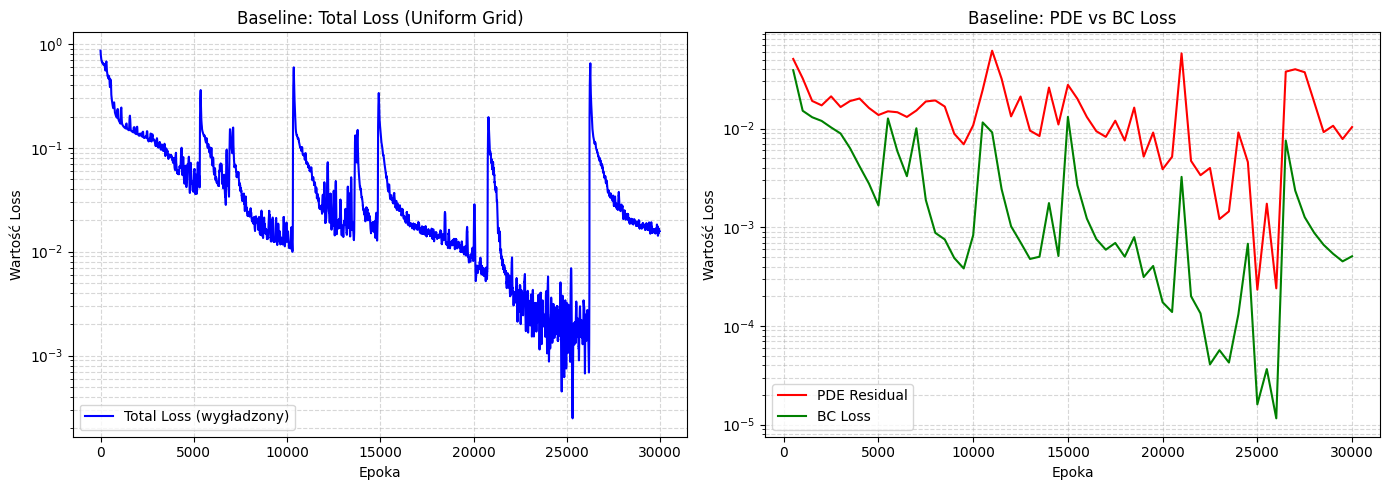

In [8]:
import time, tracemalloc

# ── Reprodukowalność ──────────────────────────────────────────────────────────
torch.manual_seed(PINN_INIT_SEED)
np.random.seed(PINN_INIT_SEED)
if device.type == "cuda":
    torch.cuda.manual_seed_all(PINN_INIT_SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# ── Inicjalizacja ─────────────────────────────────────────────────────────────
pinn = PINN(LAYERS, NEURONS_PER_LAYER, act=nn.Tanh()).to(device)

x_domain = (0.0, LENGTH)
y_domain = (0.0, LENGTH)

loss_fn = Loss(
    x_domain, y_domain,
    N_POINTS, N_BND_POINTS,
    device,
    WEIGHT_RESIDUAL, WEIGHT_BOUNDARY,
    E, NU
)

# ── Pomiar czasu i pamięci ────────────────────────────────────────────────────
if device.type == "cuda":
    torch.cuda.reset_peak_memory_stats(device)
tracemalloc.start()
t_start = time.perf_counter()

print(f"Rozpoczynam trening Baseline (Uniform Sampling, {EPOCHS} epok)…")
trained_pinn, histories = train_model(pinn, loss_fn, LEARNING_RATE, EPOCHS, LOG_INTERVAL)

t_end = time.perf_counter()
_, peak_cpu_bytes = tracemalloc.get_traced_memory()
tracemalloc.stop()

training_time   = t_end - t_start
peak_cpu_mb     = peak_cpu_bytes / 1024**2
peak_gpu_mb     = torch.cuda.max_memory_allocated(device) / 1024**2 if device.type == "cuda" else 0.0

final_total, final_pde, final_bc = loss_fn.verbose(trained_pinn)

print(f"\nCzas treningu      : {training_time:.1f} s")
print(f"RAM szczytowo (CPU): {peak_cpu_mb:.1f} MB")
print(f"RAM szczytowo (GPU): {peak_gpu_mb:.1f} MB")
print(f"Końcowy PDE Res    : {final_pde.item():.4e}")
print(f"Końcowy BC Loss    : {final_bc.item():.4e}")

# ── Wizualizacja ──────────────────────────────────────────────────────────────
def running_average(y, window=50):
    cumsum = np.cumsum(np.insert(y, 0, 0))
    return (cumsum[window:] - cumsum[:-window]) / float(window)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=100)

# Lewy wykres: wygładzony total loss
axes[0].plot(running_average(histories["loss_history"]), color="blue", label="Total Loss (wygładzony)")
axes[0].set_title("Baseline: Total Loss (Uniform Grid)")
axes[0].set_yscale("log")
axes[0].set_xlabel("Epoka")
axes[0].set_ylabel("Wartość Loss")
axes[0].grid(True, which="both", ls="--", alpha=0.5)
axes[0].legend()

# Prawy wykres: PDE i BC historia co LOG_INTERVAL epok
ep = histories["history_epochs"]
axes[1].plot(ep, histories["pde_history"], color="red",   label="PDE Residual")
axes[1].plot(ep, histories["bc_history"],  color="green", label="BC Loss")
axes[1].set_title("Baseline: PDE vs BC Loss")
axes[1].set_yscale("log")
axes[1].set_xlabel("Epoka")
axes[1].set_ylabel("Wartość Loss")
axes[1].grid(True, which="both", ls="--", alpha=0.5)
axes[1].legend()

plt.tight_layout()
plt.show()


## 7. Zapis Wyników do Pliku

**Co realizuje ta komórka:**
Zapisujemy wszystkie metryki i historię trenowania do pliku `results/baseline_results.npz`. Plik ten jest wczytywany przez `PINN_elasticity_comparison.ipynb` do zbiorczego porównania metod.

**Zapisywane dane:**
| Klucz | Opis |
|---|---|
| `loss_history` | Historia całkowitej straty, co epoka |
| `pde_history` | Historia PDE residual, co `LOG_INTERVAL` epok |
| `bc_history` | Historia BC Loss, co `LOG_INTERVAL` epok |
| `history_epochs` | Epoki odpowiadające `pde_history` / `bc_history` |
| `final_pde` | Końcowy PDE Residual |
| `final_bc` | Końcowy BC Loss |
| `training_time_s` | Czas treningu (sekundy) |
| `peak_cpu_mb` | Szczytowe RAM (CPU) w MB |
| `peak_gpu_mb` | Szczytowe VRAM (GPU) w MB |
| `n_collocation_points` | Liczba punktów kolokacji (900) |
| `method_name` | Etykieta metody do wykresów |
| `pinn_init_seed` | Seed inicjalizacji (42) |


In [9]:
import os

results_dir = os.path.join(os.path.dirname(os.path.abspath("__file__")), "results")
os.makedirs(results_dir, exist_ok=True)
save_path = os.path.join(results_dir, "baseline_results.npz")

np.savez(
    save_path,
    # Historia trenowania
    loss_history    = histories["loss_history"],
    pde_history     = histories["pde_history"],
    bc_history      = histories["bc_history"],
    history_epochs  = histories["history_epochs"],
    # Metryki końcowe
    final_pde       = np.array(final_pde.item()),
    final_bc        = np.array(final_bc.item()),
    # Zasoby
    training_time_s = np.array(training_time),
    peak_cpu_mb     = np.array(peak_cpu_mb),
    peak_gpu_mb     = np.array(peak_gpu_mb),
    # Metadane
    n_collocation_points = np.array(N_POINTS ** 2),
    method_name          = np.array("Baseline (Uniform Grid, bc-fixed, 30k)"),
    pinn_init_seed       = np.array(PINN_INIT_SEED),
    epochs               = np.array(EPOCHS),
    lr                   = np.array(LEARNING_RATE),
    lr_schedule          = np.array("fixed_0.002"),
)

print(f"Wyniki zapisane do: {save_path}")


Wyniki zapisane do: /home/marcin/Pulpit/doktorat/pinn-notebooks/results/baseline_results.npz
